In [2]:
!pip install segment-anything opencv-python numpy

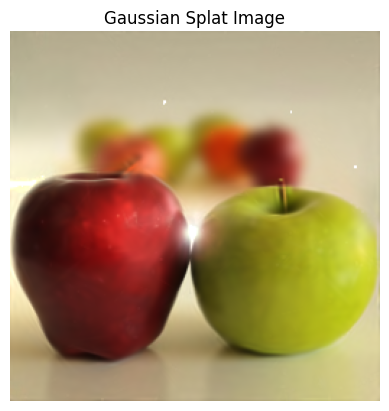

In [3]:
import numpy as np
import cv2
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import matplotlib.pyplot as plt

gs = np.load("pear_apple_gs.npy")

if gs.max() > 1:
    gs = gs / 255.0

plt.imshow(gs)
plt.title("Gaussian Splat Image")
plt.axis("off")
plt.show()

In [4]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-03-19 16:59:36--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.157.254.102, 108.157.254.124, 108.157.254.15, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|108.157.254.102|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  15.9MB/s    in 4.6s    

2025-03-19 16:59:41 (77.2 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [6]:
gs_uint8 = (gs * 255).astype(np.uint8)

In [7]:
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth").cuda()
mask_generator = SamAutomaticMaskGenerator(sam)

masks = mask_generator.generate(gs_uint8)

instance_mask = np.zeros_like(gs_uint8, dtype=np.uint8)

for i, mask in enumerate(masks):
    color = np.random.randint(0, 255, (3,), dtype=np.uint8)  # Random color for each mask
    instance_mask[mask['segmentation']] = color

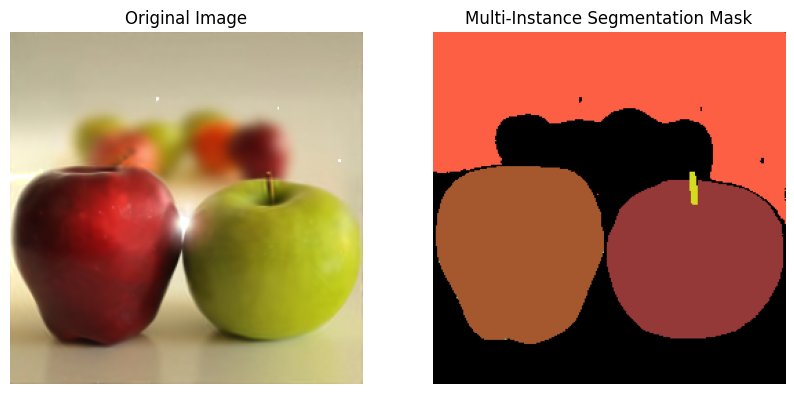

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gs_uint8)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(instance_mask)
plt.title("Multi-Instance Segmentation Mask")
plt.axis("off")

plt.show()


In [9]:
np.save("multi_instance_mask.npy", instance_mask)
cv2.imwrite("multi_instance_mask.png", cv2.cvtColor(instance_mask, cv2.COLOR_RGB2BGR))

True

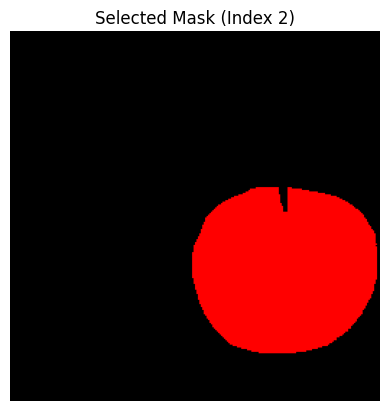

In [10]:
# Display the 3rd mask (index 2)
single_mask = np.zeros_like(gs_uint8, dtype=np.uint8)

selected_mask = masks[2]['segmentation']  # Change index as desired

single_mask[selected_mask] = [255, 0, 0]  # Red-colored mask

plt.imshow(single_mask)
plt.title("Selected Mask (Index 2)")
plt.axis("off")
plt.show()

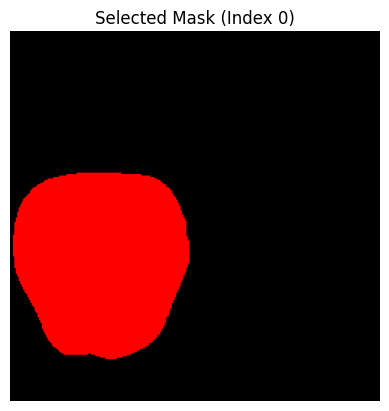

In [11]:
# Display the 1st mask (index 0)
single_mask = np.zeros_like(gs_uint8, dtype=np.uint8)

selected_mask = masks[0]['segmentation']  # Change index as desired

single_mask[selected_mask] = [255, 0, 0]  # Red-colored mask

plt.imshow(single_mask)
plt.title("Selected Mask (Index 0)")
plt.axis("off")
plt.show()


In [13]:
# Extract masks for Mask 0 and Mask 2
mask0 = masks[0]['segmentation']
mask2 = masks[2]['segmentation']

min_size_mask = mask0 if np.sum(mask0) < np.sum(mask2) else mask2
max_size_mask = mask2 if min_size_mask is mask0 else mask0

image_copy = gs_uint8.copy()

content_min = image_copy[min_size_mask].copy()
content_max = image_copy[max_size_mask].copy()

In [34]:
shifted_image = np.copy(gs_uint8)

# Extract mask 0 and mask 2
mask_0 = masks[0]['segmentation']
mask_2 = masks[2]['segmentation']

rows, cols = mask_0.shape
shifted_mask_0 = np.zeros_like(mask_0, dtype=np.bool_)
shifted_mask_0[:, 130:] = mask_0[:, :-130]  # Shift right by 130 units

shifted_mask_2 = np.zeros_like(mask_2, dtype=np.bool_)
shifted_mask_2[:, :-120] = mask_2[:, 120:]  # Shift left by 120 units

In [35]:
shifted_image[mask_0] = [255, 255, 255]
shifted_image[mask_2] = [255, 255, 255]

shifted_image[shifted_mask_0] = gs_uint8[mask_0]
shifted_image[shifted_mask_2] = gs_uint8[mask_2]

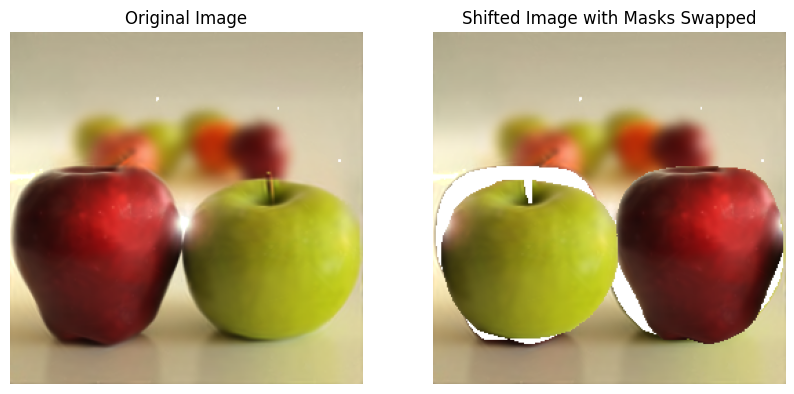

In [36]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gs_uint8)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(shifted_image)
plt.title("Shifted Image with Masks Swapped")
plt.axis("off")

plt.show()


In [37]:
cv2.imwrite("shifted_image.png", cv2.cvtColor(shifted_image, cv2.COLOR_RGB2BGR))
np.save("shifted_image.npy", shifted_image)